In [57]:
from google.colab import files

uploaded = files.upload()

Saving data.csv to data.csv


In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
df = pd.read_csv("data.csv")

df.head()

,ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
0,1,143.635030,1.0,3.0,3.0,1967.0,1.0,1.0,48.0,8.297631,5.935734,6021
1,2,287.678577,1.0,2.0,1.0,1949.0,0.0,1.0,37.0,6.061466,10.827392,5914
2,3,232.998485,1.0,3.0,2.0,1923.0,1.0,0.0,14.0,2.911442,6.904599,4645
3,4,199.664621,5.0,2.0,2.0,1918.0,0.0,0.0,17.0,2.070949,8.284019,5831
4,5,89.004660,4.0,3.0,3.0,1999.0,1.0,0.0,34.0,1.523278,14.648277,6199


In [60]:
print(df.shape)

print(df.info())

print(df.describe())

(500, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  500 non-null    int64  
 1   Square_Feet         495 non-null    float64
 2   Num_Bedrooms        494 non-null    float64
 3   Num_Bathrooms       499 non-null    float64
 4   Num_Floors          497 non-null    float64
 5   Year_Built          498 non-null    float64
 6   Has_Garden          494 non-null    float64
 7   Has_Pool            499 non-null    float64
 8   Garage_Size         496 non-null    float64
 9   Location_Score      499 non-null    float64
 10  Distance_to_Center  499 non-null    float64
 11  Price               500 non-null    int64  
dtypes: float64(10), int64(2)
memory usage: 47.0 KB
None
               ID  Square_Feet  Num_Bedrooms  Num_Bathrooms  Num_Floors  \
count  500.000000   495.000000    494.000000     499.000000  497.00

In [61]:
print(df.isnull().sum())

ID                    0
Square_Feet           5
Num_Bedrooms          6
Num_Bathrooms         1
Num_Floors            3
Year_Built            2
Has_Garden            6
Has_Pool              1
Garage_Size           4
Location_Score        1
Distance_to_Center    1
Price                 0
dtype: int64


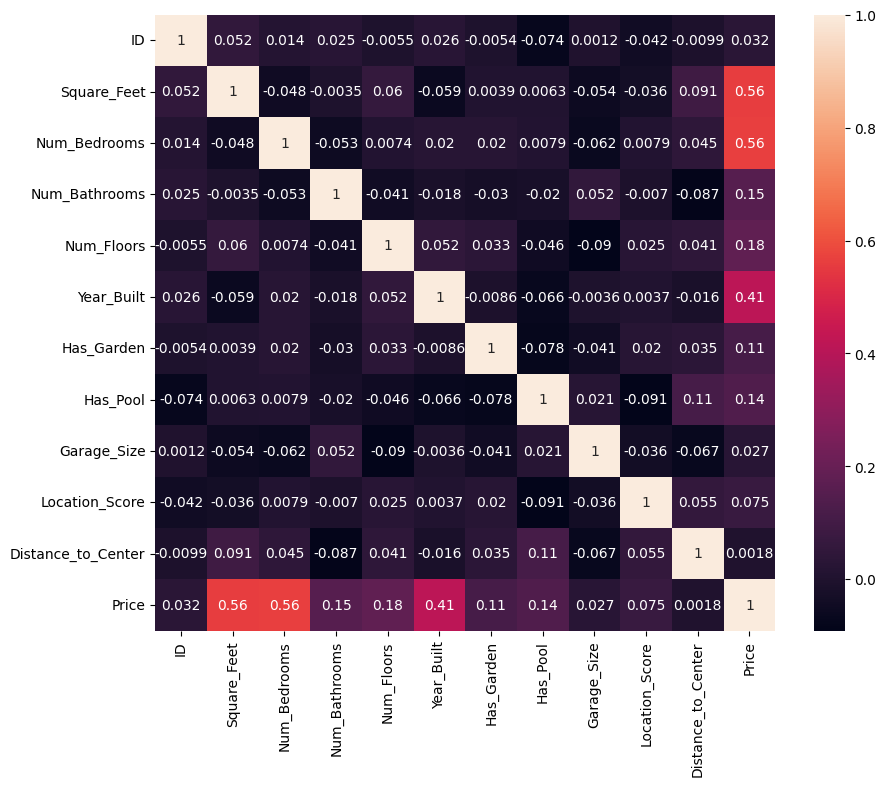

In [62]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [63]:
X = df.drop(["Price", "ID"], axis=1)
y = df["Price"]

In [64]:
X = X.fillna(X.mean(numeric_only=True))
X = pd.get_dummies(X, drop_first=True)

In [65]:
X = X.values
y = y.values.reshape(-1,1)

In [66]:
ones = np.ones((X.shape[0],1))
X = np.hstack((ones, X))

In [67]:
beta = np.linalg.inv(X.T @ X) @ X.T @ y

print(beta)

[[-2.93253871e+04]
 [ 1.01705900e+01]
 [ 5.07616258e+02]
 [ 2.93648594e+02]
 [ 2.06554769e+02]
 [ 1.53875277e+01]
 [ 3.00681963e+02]
 [ 4.76879350e+02]
 [ 1.05404874e+01]
 [ 4.81557589e+01]
 [-1.92438341e+01]]


In [68]:
y_pred = X @ beta

In [69]:
mse = np.mean((y - y_pred)**2)

print("MSE =", mse)

MSE = 47777.367927648134


In [70]:
rss = np.sum((y - y_pred)**2)

print("RSS =", rss)

RSS = 23888683.963824067


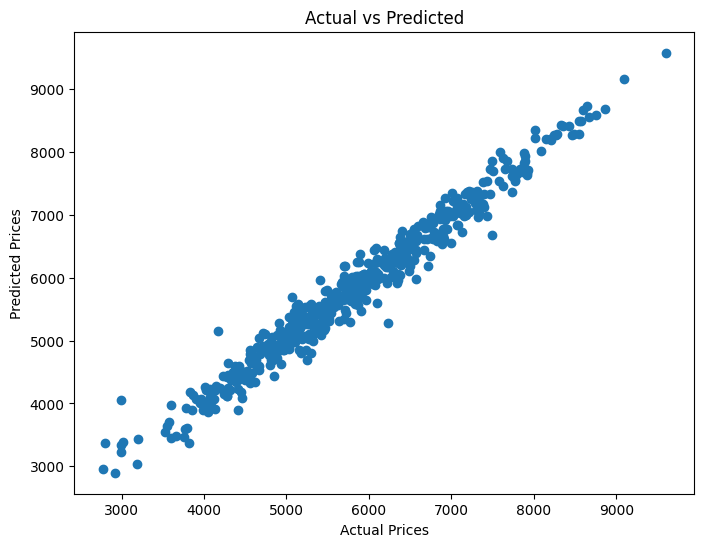

In [71]:
plt.figure(figsize=(8,6))
plt.scatter(y, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()

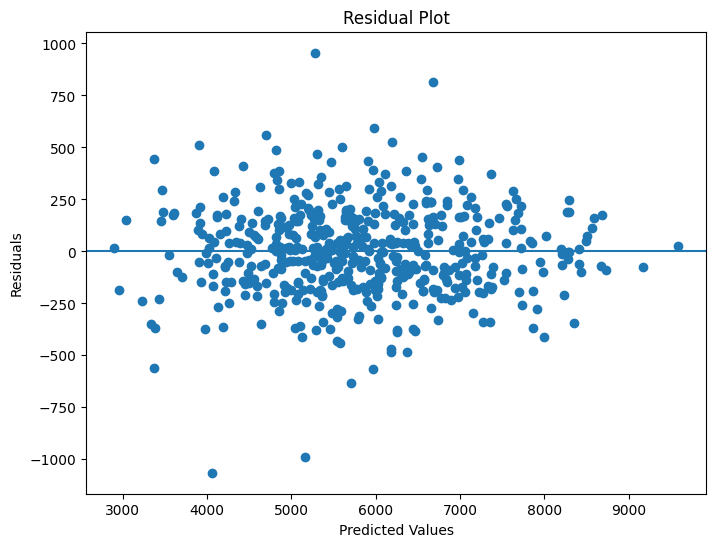

In [72]:
residuals = y - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

BONUS TASK


In [73]:
# Standardization

X_std = (X[:,1:] - np.mean(X[:,1:], axis=0)) / np.std(X[:,1:], axis=0)

In [74]:
# Add bias column again

ones = np.ones((X_std.shape[0],1))

X_std = np.hstack((ones, X_std))

In [75]:
# Linear Regression after standardization

beta_std = np.linalg.inv(X_std.T @ X_std) @ X_std.T @ y

y_pred_std = X_std @ beta_std

In [76]:
# MSE and RSS

mse_std = np.mean((y - y_pred_std)**2)

rss_std = np.sum((y - y_pred_std)**2)

print("MSE after standardization =", mse_std)
print("RSS after standardization =", rss_std)

MSE after standardization = 47777.36792764817
RSS after standardization = 23888683.963824086


Bonus Task 1: Standardization

The independent variables were standardized to have mean 0 and standard deviation 1.

After standardization:

MSE = 47777.37
RSS = 23888683.96

The model performance remained similar, indicating that standardization did not significantly affect prediction accuracy for this dataset.

In [77]:
print(df.columns)

Index(['ID', 'Square_Feet', 'Num_Bedrooms', 'Num_Bathrooms', 'Num_Floors',
       'Year_Built', 'Has_Garden', 'Has_Pool', 'Garage_Size', 'Location_Score',
       'Distance_to_Center', 'Price'],
      dtype='object')


In [78]:
# Polynomial Features

X_poly = pd.DataFrame()

# Fill missing values in 'Square_Feet' before creating polynomial features
df_square_feet_filled = df["Square_Feet"].fillna(df["Square_Feet"].mean())

# Standardize Square_Feet for better numerical stability in polynomial regression
square_feet_standardized = (df_square_feet_filled - df_square_feet_filled.mean()) / df_square_feet_filled.std()

X_poly["Square_Feet"] = square_feet_standardized
X_poly["Square_Feet_Squared"] = square_feet_standardized ** 2

In [79]:
y_poly = df["Price"].values.reshape(-1,1)

In [80]:
X_poly = X_poly.values

ones = np.ones((X_poly.shape[0],1))

X_poly = np.hstack((ones, X_poly))

In [81]:
beta_poly = np.linalg.inv(X_poly.T @ X_poly) @ X_poly.T @ y_poly

y_pred_poly = X_poly @ beta_poly

In [82]:
mse_poly = np.mean((y_poly - y_pred_poly)**2)

rss_poly = np.sum((y_poly - y_pred_poly)**2)

print("Polynomial MSE =", mse_poly)

print("Polynomial RSS =", rss_poly)

Polynomial MSE = 1027208.3911894865
Polynomial RSS = 513604195.59474325


In [83]:
print("Linear Regression MSE =", mse)

print("Polynomial Regression MSE =", mse_poly)

print()

print("Linear Regression RSS =", rss)

print("Polynomial Regression RSS =", rss_poly)

Linear Regression MSE = 47777.367927648134
Polynomial Regression MSE = 1027208.3911894865

Linear Regression RSS = 23888683.963824067
Polynomial Regression RSS = 513604195.59474325


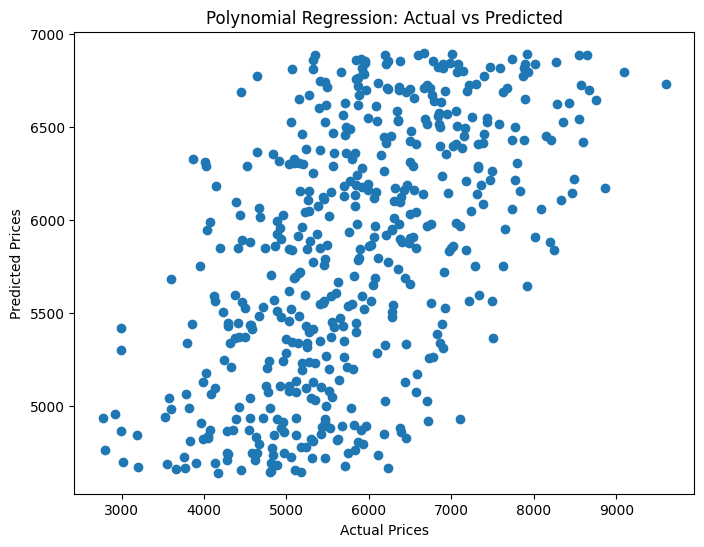

In [84]:
plt.figure(figsize=(8,6))

plt.scatter(y_poly, y_pred_poly)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Polynomial Regression: Actual vs Predicted")

plt.show()

Bonus Task 2: Polynomial Regression

Polynomial features were created using the Square_Feet variable by adding a squared term.

After training the polynomial regression model, the performance metrics were:

Polynomial MSE = 1027208.39
Polynomial RSS = 513604195.59

These values are higher than those of the linear regression model.

Therefore, for this dataset, the simple linear regression model performed better than the polynomial regression model. Adding polynomial features did not improve prediction accuracy.

Conclusion

A linear regression model was implemented from scratch using the matrix-based method.

The model was evaluated using MSE and RSS and showed good agreement between actual and predicted house prices.

Standardization of the independent variables did not significantly affect model performance.

Polynomial regression using Square_Feet and its squared term was also tested. However, the polynomial model produced higher MSE and RSS values than the linear model, indicating poorer performance on this dataset.

Hence, the linear regression model was the most suitable model among the methods tested.